In [ ]:
!pip install pyagrum
!pip install numpy
!pip install causal-learn
!pip install pandas
!pip install pingouin
!pip install bnlearn
!pip install graphviz
!pip install IPython

In [1]:
import sys
import os
sys.path.append(os.getcwd())

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
from FCI_family import *
from FCI_pyagrum import *
from drawing_graph import * 
import graphviz
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\bnlearn\__init__.py:22: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.13.2 causes joblib/loky crashes.
  warnings.warn(


In [3]:
model = bn.import_DAG("asia")

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


In [ ]:
bn.plot(model)

In [4]:
df = bn.sampling(model, n=100000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,1,1,0,1,0,1,1,0
1,1,1,0,1,1,1,1,1
2,1,1,1,1,1,1,1,0
3,1,1,1,1,0,1,1,0
4,1,1,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...
99995,1,1,1,1,0,1,1,0
99996,1,1,0,1,0,1,1,0
99997,1,1,0,1,0,1,1,0
99998,1,1,1,1,0,1,1,0


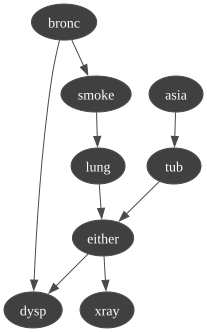

In [14]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/8 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 ind 2 | () with p-value 0.077611

0 ind 3 | () with p-value 0.150997

0 ind 4 | () with p-value 0.267982

0 dep 5 | () with p-value 0.009058

0 ind 6 | () with p-value 0.103567

0 ind 7 | () with p-value 0.598930

1 dep 0 | () with p-value 0.000000

1 ind 2 | () with p-value 0.443410

1 ind 3 | () with p-value 0.805365

1 dep 4 | () with p-value 0.039827

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

1 dep 7 | () with p-value 0.000000

2 ind 0 | () with p-value 0.077611

2 ind 1 | () with p-value 0.443410

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.000000

2 dep 5 | () with p-value 0.000000

2 dep 6 | () with p-value 0.000000

2 dep 7 | () with p-value 0.000000

3 ind 0 | () with p-value 0.150997

3 ind 1 | () with p-value 0.805365

3 dep 2 | () with p-value 0.000000

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.000000

3 dep 6 | () with p-value 0.000000

3 dep 7 | () with p-value 0.

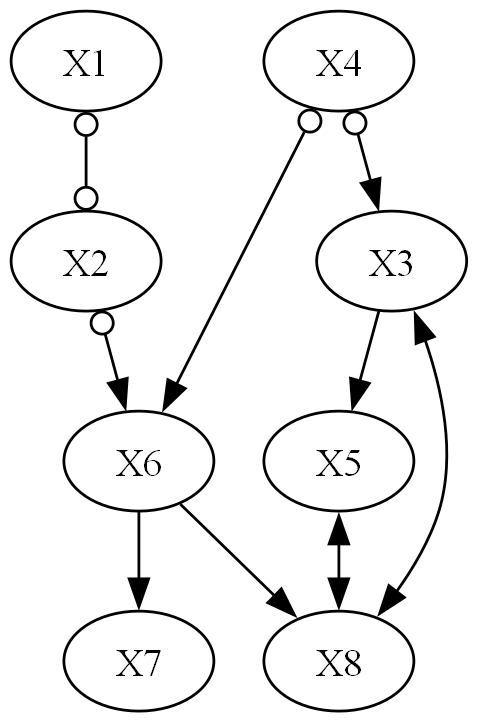

In [15]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=chisq,
    alpha=0.05,
    verbose=True,
    stable = False
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

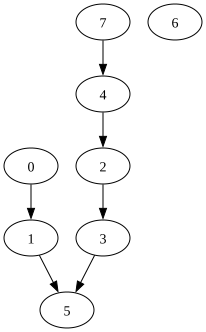

In [5]:
fci_totally_gum = raw_skeleton(df, 0.05, stable=True)
mg = fci_totally_gum.return_PDAG()
meek = gum.MeekRules()
pdag = meek.propagateToDAG(mg)
graph = graphviz.Source(pdag.toDot())
graph

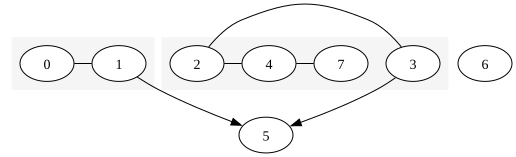

In [13]:
fci_pc = FCI_PC_pyagrum(df, 0.05, stable=True)
pdag = fci_pc.return_PDAG()
graph = graphviz.Source(pdag.toDot())
graph

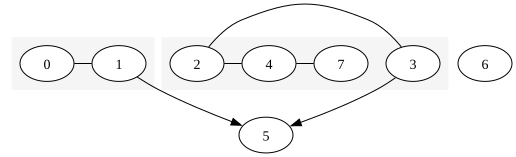

In [12]:
fci_zhang = FCI_Zhang_pyagrum(df, 0.05, stable=True)
pdag = fci_zhang.return_PDAG()
graph = graphviz.Source(pdag.toDot())
graph

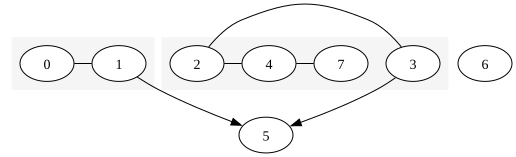

In [18]:
fci_ethz = FCI_ETHZ_pyagrum(df, 0.05, stable=False)
pdag = fci_ethz.return_PDAG()
graph = graphviz.Source(pdag.toDot())
graph

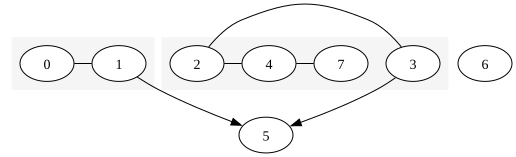

In [17]:
afci = AFCI_Zhang_pyagrum(df, 0.05, stable=False)
pdag = afci.return_PDAG()
graph = graphviz.Source(pdag.toDot())
graph

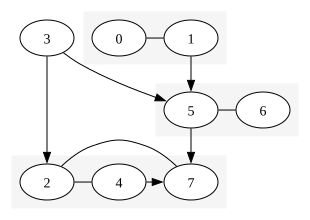

In [7]:
fci_pc_bis = create_instance(df, FCI_PC)
pdag = create_graph(fci_pc_bis)
graph = graphviz.Source(pdag.toDot())
graph

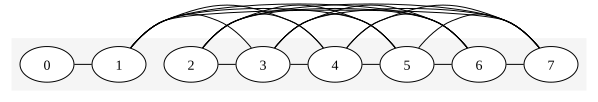

In [8]:
fci_zhang_bis = create_instance(df, FCI_Zhang)
pdag = create_graph(fci_zhang_bis)
graph = graphviz.Source(pdag.toDot())
graph

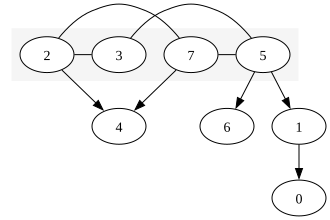

In [10]:
fci_ethz_bis = create_instance(df, FCI_ETHZ)
pdag = create_graph(fci_ethz_bis)
graph = graphviz.Source(pdag.toDot())
graph

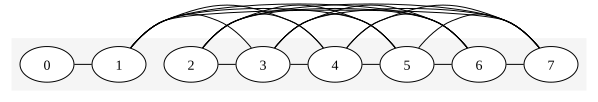

In [9]:
afci_bis = create_instance(df, FCI_Zhang)
pdag = create_graph(afci_bis)
graph = graphviz.Source(pdag.toDot())
graph